# 👩‍💻 Feature Scaling for Loan Approval Prediction

## 📋 Overview
In this lab, you'll work with a loan approval dataset to implement feature scaling techniques—a critical preprocessing step for machine learning models. You'll transform raw data features into consistent scales to improve model performance and interpretability. By the end, you'll have a scaled dataset ready for building a loan approval prediction model and understand how different scaling methods impact your results.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Apply different feature scaling techniques (StandardScaler and MinMaxScaler) to prepare data for machine learning

- Visualize and compare feature distributions before and after scaling

- Evaluate how feature scaling affects model performance for loan approval prediction

- Select appropriate scaling methods based on data characteristics and model requirements

## 🚀 Starting Point
Access the starter code provided below. You'll need to load the loan approval prediction dataset during the lab.

Required tools/setup:

- Python 3.x
- Pandas, NumPy, Scikit-learn, Matplotlib/Seaborn libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  # Import both scalers
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import warnings

# Load the dataset
df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip() # Remove whitespace
print(df.shape)
df.head(2)

(4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


In [2]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## Task 1: Explore the Dataset
**Context:** Data scientists need to understand their data before applying preprocessing techniques. In a real-world loan approval system, understanding feature distributions helps identify which scaling methods would be most appropriate.

**Steps:**

1. Examine the first few rows of the dataset using`head()`method
2. Display summary statistics with `describe()` to identify features with varying scales
3. Check for missing values using `isnull().sum()`
4. Examine the data types and convert categorical variables as needed

In [3]:
# Your code for dataset exploration

# View first few rows
print("First 5 rows:")
display(df.head())
print("="*100)
print()

# Summary statistics
print("\nSummary statistics:")
display(df.describe().T)
print("="*100)
print()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())
print("="*100)
print()

# Data types
print("\nData types:")
print(df.dtypes)

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected




Summary statistics:


,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0




Missing values:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


Data types:
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object


In [4]:
categorical_cols = ['education', 'self_employed']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


💡 **Tip:** Pay special attention to numerical features like income and loan amount. Their scales likely differ significantly from other features.

⚙️ **Test Your Work:**

- You should see features like income and loan amount having much larger values than others
- Confirm whether any missing values need to be addressed

## Task 2: Visualize Feature Distributions
**Context:** Visualization helps identify which features require scaling and provides a baseline for comparing scaled results.

**Steps:**

1. Create histograms of numerical features using `matplotlib.pyplot.hist()` or `seaborn.histplot()`
2. Generate a boxplot to visualize the range and outliers using `seaborn.boxplot()`
3. Create a correlation matrix heatmap using `seaborn.heatmap(df.corr())` to understand relationships between features

In [5]:
# Select numerical columns for visualization from the original DataFrame
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

Generating histograms for numerical features...


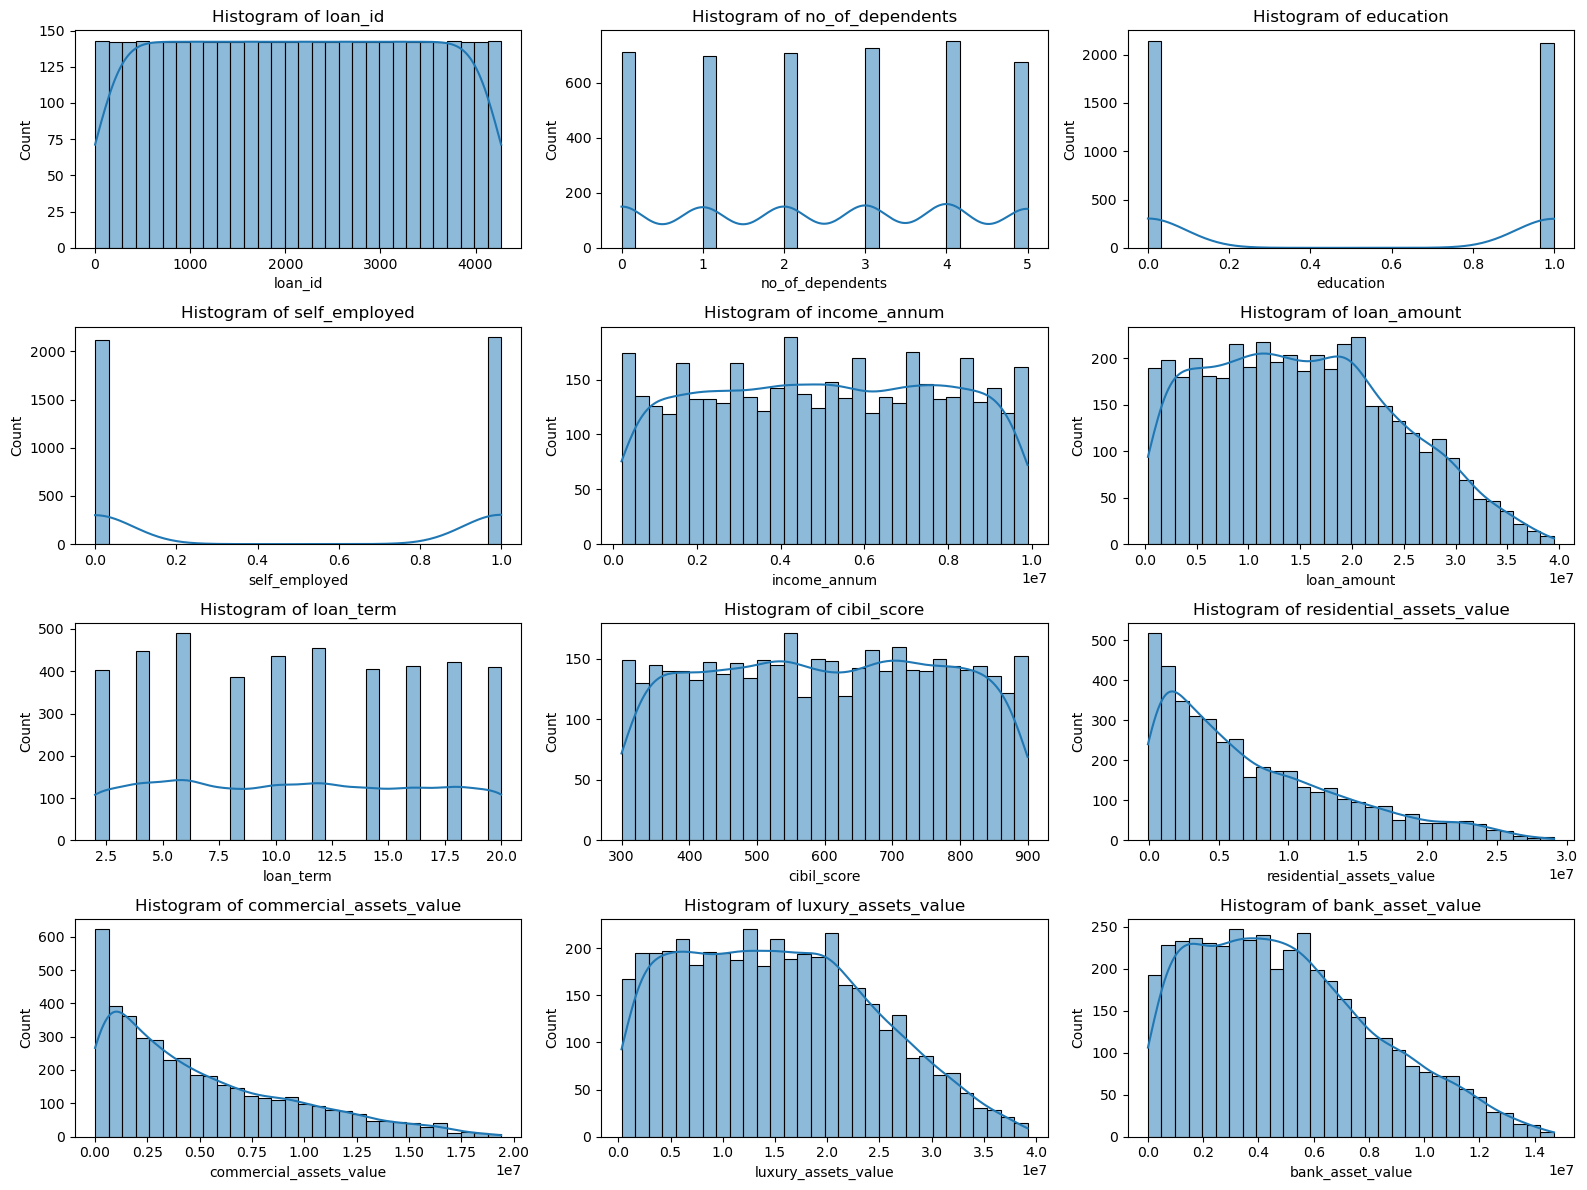

In [6]:
# Your code for feature visualization

# Histograms for numerical features
print("Generating histograms for numerical features...")
plt.figure(figsize=(16, 12))
for idx, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, idx + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


Generating boxplots for numerical features...


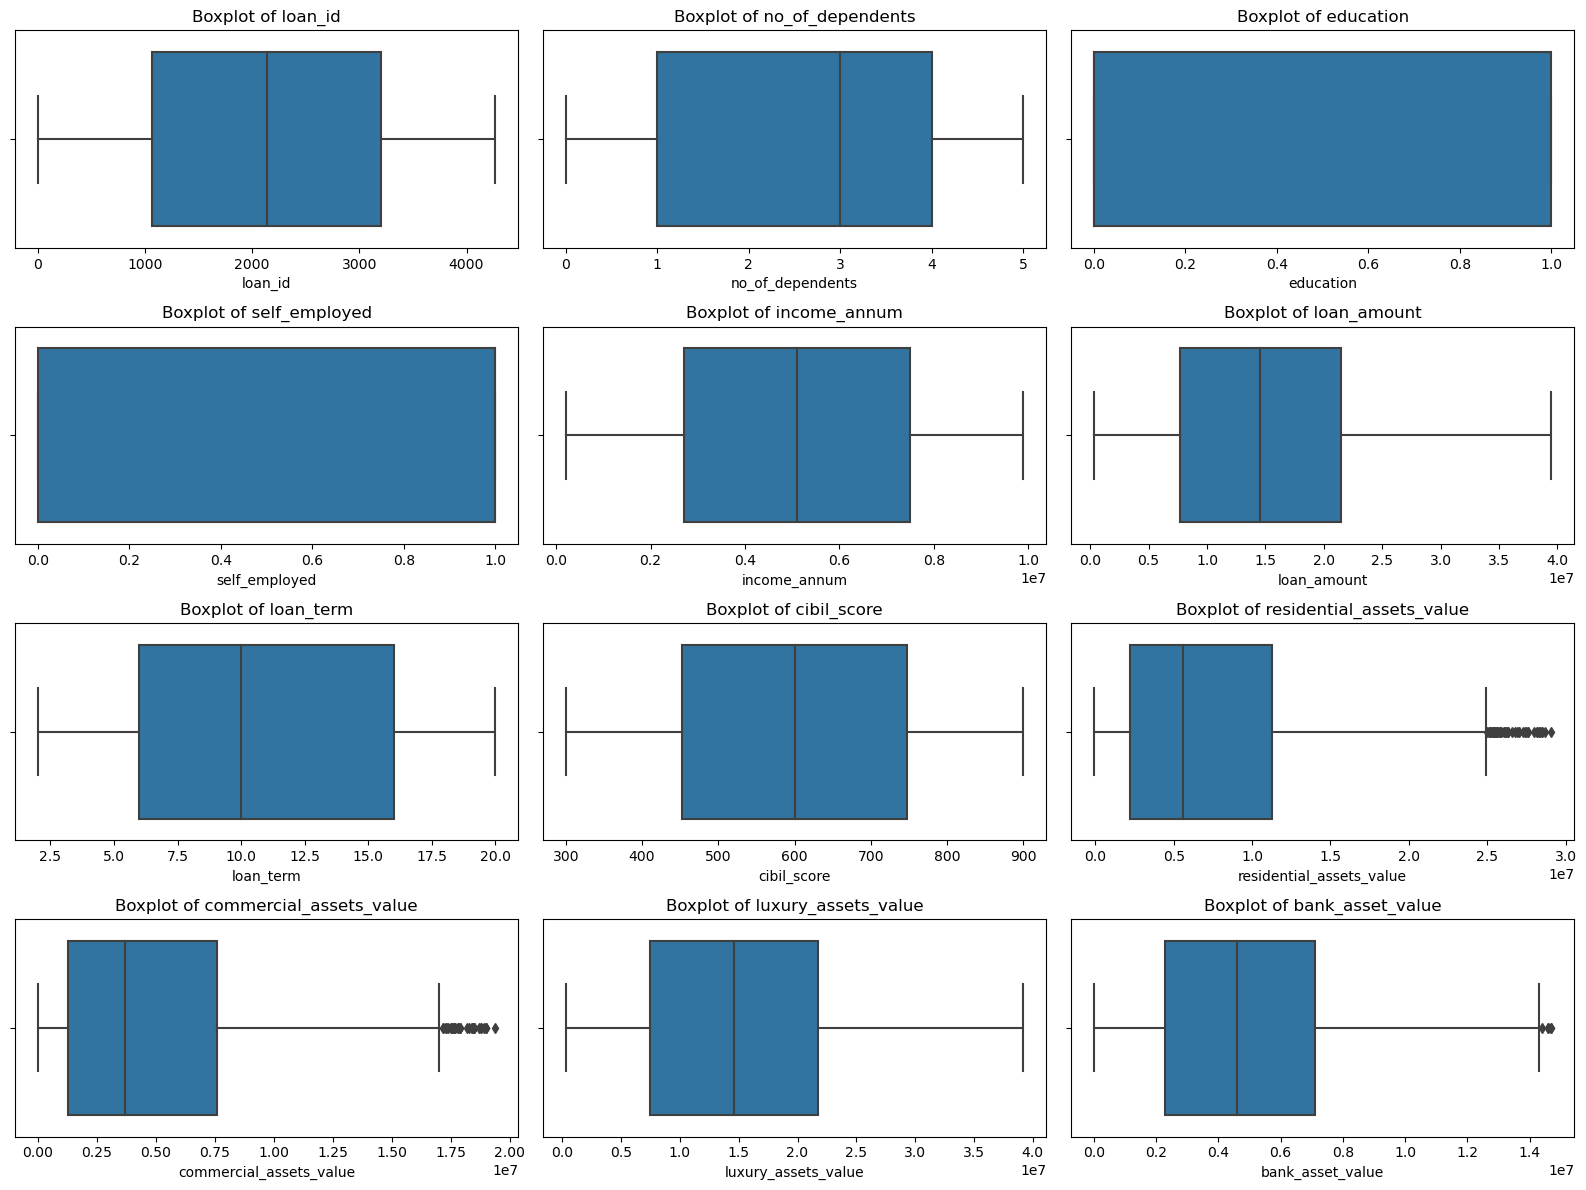

In [7]:
# Boxplots for numerical features
print("Generating boxplots for numerical features...")
plt.figure(figsize=(16, 12))
for idx, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, idx + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Generating correlation heatmap...


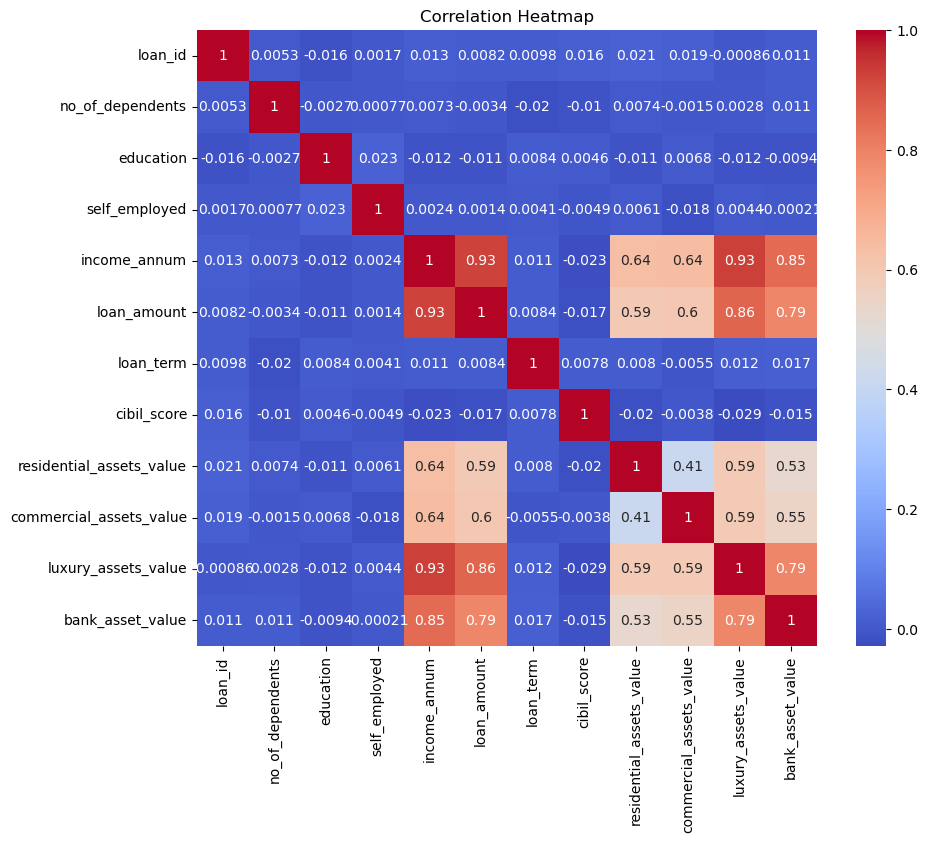

In [8]:
# Correlation heatmap
print("Generating correlation heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

💡 **Tip:** Compare feature ranges side-by-side using subplots to clearly see scale differences.

⚙️ **Test Your Work:**

- Your histograms should clearly show different scales across features
- The boxplots should reveal potential outliers that might affect scaling choices

## Task 3: Apply Standard Scaling
**Context:** StandardScaler transforms features to have a mean of 0 and standard deviation of 1, which is crucial for many machine learning algorithms, particularly those that assume normally distributed data.

**Steps:**

1. Separate features and target variable
2. Split data into training and testing sets using `train_test_split()`
3. Initialize a `StandardScaler object`
4. Fit the scaler on the training data and transform both training and testing data
5. Visualize the scaled features to confirm transformation

In [9]:
df['loan_status']= df['loan_status'].str.strip()
print(df['loan_status'].value_counts(dropna=False))
print(df['loan_status'].value_counts(dropna=False, normalize=True))

df['loan_status']= df['loan_status'].map({"Approved":1, "Rejected":0})
print(df['loan_status'].value_counts(dropna=False, normalize=True))

Approved    2656
Rejected    1613
Name: loan_status, dtype: int64
Approved    0.62216
Rejected    0.37784
Name: loan_status, dtype: float64
1    0.62216
0    0.37784
Name: loan_status, dtype: float64


In [10]:
# Your code for standard scaling

X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']
print(f"\nFeatures shape: {X.shape}")

print("\n--- Splitting Dataset ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training features shape: {X_train.shape}")

print("\n--- Applying Feature Scaling ---")

numerical_features = X_train.columns.tolist()
print(f"\nApplying scaling to features: {numerical_features}")

# Apply StandardScaler
print("\nApplying StandardScaler...")
scaler_standard = StandardScaler()
X_train_scaled_standard = scaler_standard.fit_transform(X_train)
X_test_scaled_standard = scaler_standard.transform(X_test)

# Convert to DataFrame for easy plotting
X_train_scaled_standard_df = pd.DataFrame(X_train_scaled_standard, columns=X_train.columns)
X_train_scaled_standard_df.head()


Features shape: (4269, 11)

--- Splitting Dataset ---
Training features shape: (3415, 11)

--- Applying Feature Scaling ---

Applying scaling to features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Applying StandardScaler...


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,0.890718,-0.998537,-1.008528,-0.092646,-0.088677,-0.850759,1.131102,-0.235163,-1.137306,-0.444440,-0.736827
1,0.301107,-0.998537,0.991544,0.265460,0.180218,1.243433,0.194245,0.107588,0.785995,-0.048387,-0.396795
2,-0.288503,-0.998537,0.991544,1.089102,0.807638,1.243433,0.795684,2.319895,1.747645,1.304793,0.716035
3,-0.288503,1.001465,0.991544,-0.235888,-0.133492,-0.850759,1.217848,0.902149,-0.175656,-0.015383,0.066884
4,1.480328,-0.998537,-1.008528,0.516133,1.087736,-0.501727,1.038573,-0.063787,1.060752,0.061628,1.179714



Visualizing Scaled Features...


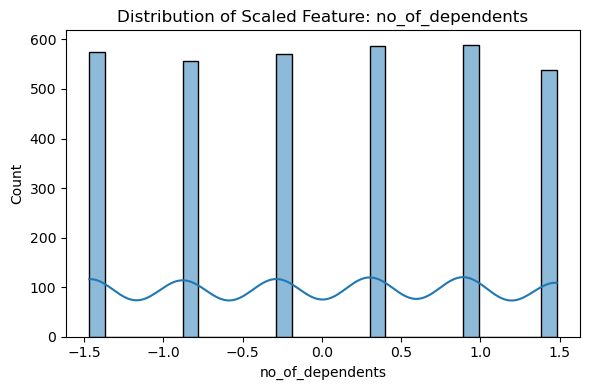

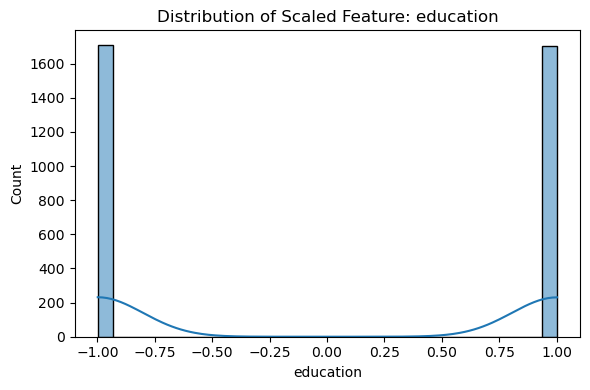

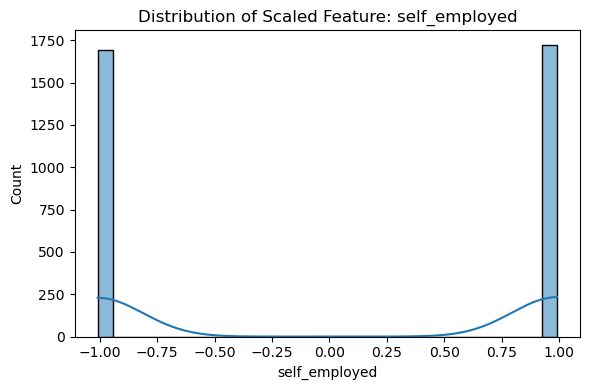

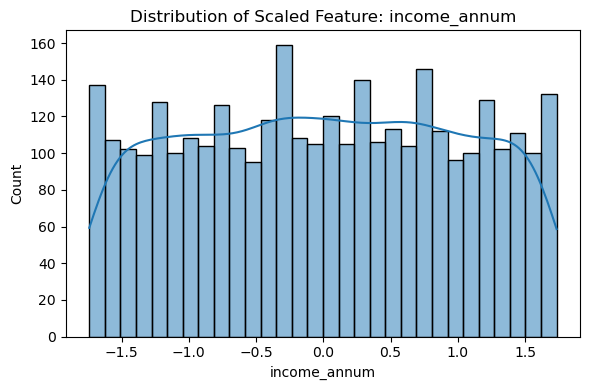

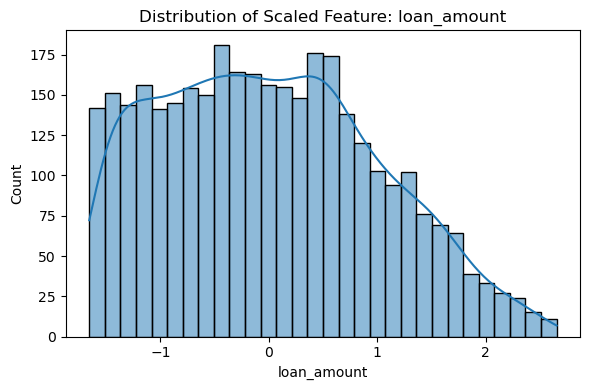

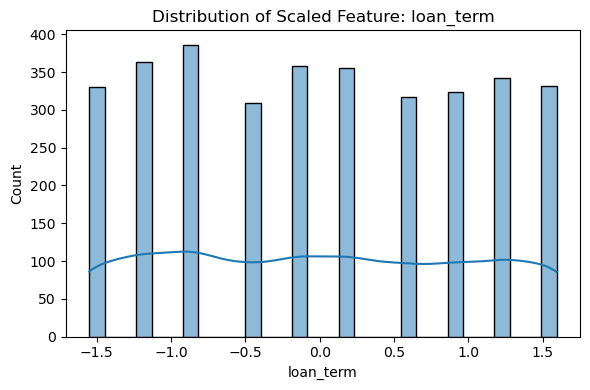

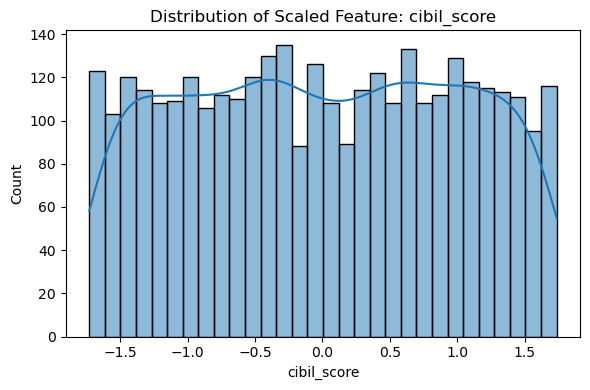

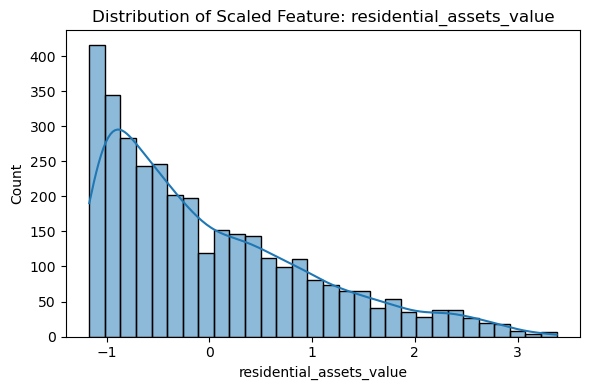

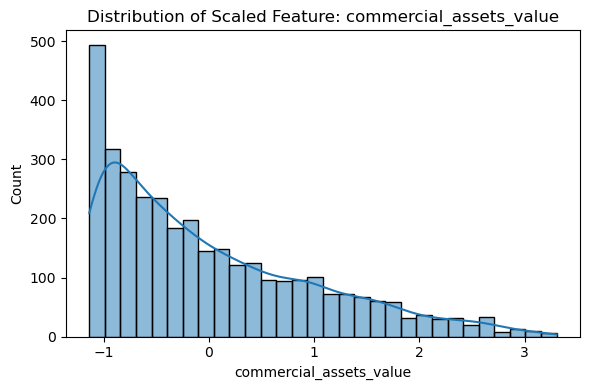

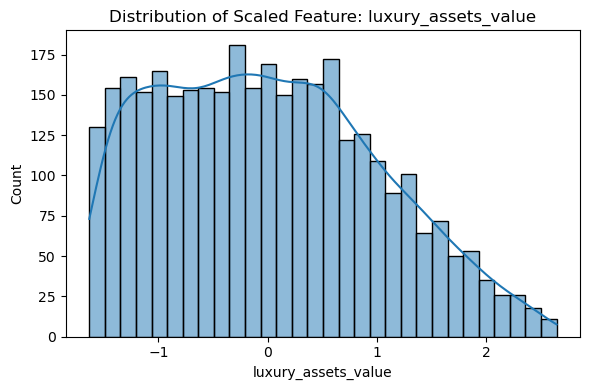

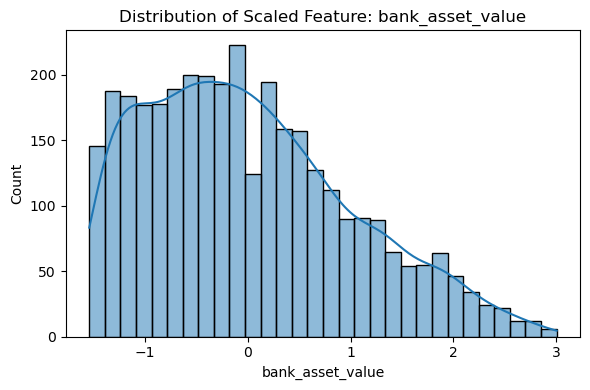

In [11]:
print("\nVisualizing Scaled Features...")
for feature in X_train_scaled_standard_df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=X_train_scaled_standard_df, x=feature, kde=True, bins=30)
    plt.title(f'Distribution of Scaled Feature: {feature}')
    plt.tight_layout()
    plt.show()

💡 **Tip:** Always fit your scaler on training data only to avoid data leakage, then apply the same transformation to test data.

⚙️ **Test Your Work:**

- Check that scaled features have a mean close to 0 and standard deviation close to 1
- Verify that the shape of your data remains unchanged after scaling

## Task 4: Apply Min-Max Scaling
**Context:** MinMaxScaler transforms features to a specific range (typically [0,1]), which is useful for algorithms that expect bounded input values.

**Steps:**

1. Initialize a `MinMaxScaler object`
2. Fit the scaler on the training data and transform both training and testing data
3. Visualize the min-max scaled features
4. Compare the distributions before and after scaling

In [12]:
# Your code for min-max scaling

# Apply MinMaxScaler
print("Applying MinMaxScaler...")
scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)

X_test_scaled_minmax = scaler_standard.transform(X_test)

# Convert back to DataFrame
X_train_scaled_minmax_df = pd.DataFrame(X_train_scaled_minmax, columns=X_train.columns)
print("Min-Max Scaling complete on training data.")

Applying MinMaxScaler...
Min-Max Scaling complete on training data.


💡 **Tip:** MinMaxScaler is sensitive to outliers, so consider how they might affect your scaled data.

⚙️ **Test Your Work:**

- Verify all scaled values fall between 0 and 1
- Compare histograms of features before and after scaling to see how distributions change

## Task 5: Build and Evaluate Models with Different Scaling Methods
**Context:** Different scaling methods can impact model performance, so it's important to compare results.

**Steps:**

1. Initialize a LogisticRegression model
2. Train separate models using unscaled, standard-scaled, and min-max-scaled data
3. Make predictions with each model
4. Compare performance using metrics like accuracy, precision, recall, and F1-score
5. Generate confusion matrices to visualize prediction results


--- Unscaled Logistic Regression ---
Accuracy:  0.6230
Precision: 0.6234
Recall:    0.9944
F1 Score:  0.7663


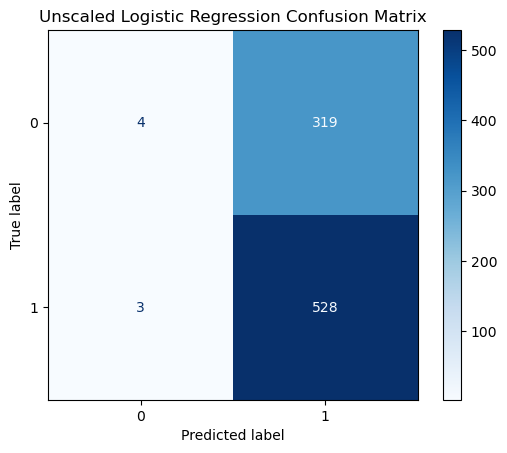


--- Standard Scaled Logistic Regression ---
Accuracy:  0.9133
Precision: 0.9208
Recall:    0.9416
F1 Score:  0.9311


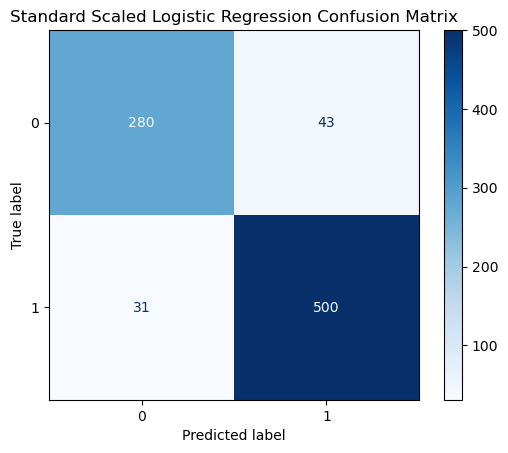


--- Min-Max Scaled Logistic Regression ---
Accuracy:  0.8044
Precision: 0.9946
Recall:    0.6893
F1 Score:  0.8142


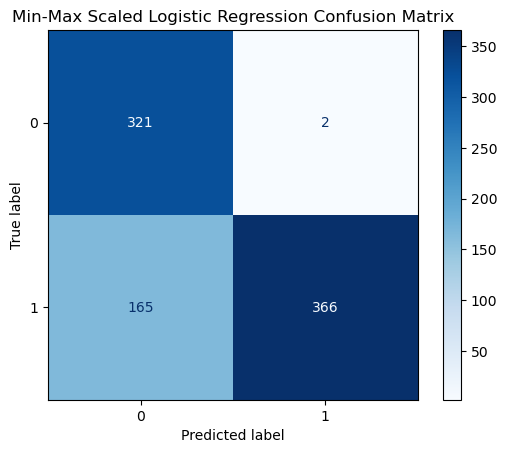

In [13]:
# Your code for model building and evaluation

# Unscaled
model_raw = LogisticRegression(max_iter=100)
model_raw.fit(X_train, y_train)

# Standard Scaled
model_std = LogisticRegression(max_iter=100)
model_std.fit(X_train_scaled_standard, y_train)

# Min-Max Scaled
model_mm = LogisticRegression(max_iter=100)
model_mm.fit(X_train_scaled_minmax, y_train)

y_pred_raw = model_raw.predict(X_test)
y_pred_std = model_std.predict(X_test_scaled_standard)
y_pred_mm = model_mm.predict(X_test_scaled_minmax)

def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_model("Unscaled Logistic Regression", y_test, y_pred_raw)
evaluate_model("Standard Scaled Logistic Regression", y_test, y_pred_std)
evaluate_model("Min-Max Scaled Logistic Regression", y_test, y_pred_mm)

💡 **Tip:** For fair comparison, use the same random state when initializing models and splitting data.

⚙️ **Test Your Work:**

- Note performance differences between models with different scaling methods
- Check if there's a clear winner among the scaling approaches

## Task 6: Document and Reflect on Results
**Context:** Documenting preprocessing steps and their impact is essential for model reproducibility and future reference.

**Steps:**

1. Summarize the impact of different scaling methods on model performance
2. Document which features benefited most from scaling
3. Explain why certain scaling methods might be more appropriate for this specific dataset
4. Reflect on how feature scaling contributes to the overall loan approval prediction task

In [14]:
# Add your documentation and reflection as comments

### Reflection

#### Why Scaling Matters for This Dataset ?
* Logistic Regression is sensitive to feature magnitudes. Without scaling, dominant features (like income) can distort the decision boundary.
* Standard Scaling centers features around zero with unit variance, which helps the model converge faster and generalize better.
* Min-Max Scaling compresses features into a fixed range (0–1), which can be useful for algorithms like neural networks but may underperform if outliers are present.

#### Reflection on Loan Approval Prediction
* Feature scaling significantly improved model performance, especially in precision and F1 score, which are critical for minimizing false approvals or rejections.
* Standard Scaling emerged as the most effective method, balancing recall and precision — ideal for high-stakes decisions like loan approvals.
* This step reinforces the importance of preprocessing in financial modeling, where raw data can mislead models without proper normalization.


## ✅ Success Checklist

- Dataset successfully loaded and explored
- Feature distributions visualized before scaling
- StandardScaler correctly applied to training and testing data
- MinMaxScaler correctly applied to training and testing data
- Model performance compared across different scaling methods
- Documentation completed with insights on scaling impact
- All code runs without errors

## 🔍 Common Issues & Solutions

**Problem:** Forgetting to fit scalers only on training data

**Solution:** Always use fit_transform() on training data and only transform() on test data

**Problem:** Poor model performance despite scaling 

**Solution:** Check for outliers that might be affecting your scaling results, or consider robust scaling methods

**Problem:** Confusion about which features to scale

**Solution:** Only scale numerical features; categorical features should be encoded separately

## 🔑 Key Points

- Feature scaling is essential for algorithms sensitive to feature magnitudes
- Different scaling methods (StandardScaler vs. MinMaxScaler) serve different purposes
- The choice of scaling method should be informed by your data distribution and model requirements
- Always scale after splitting data to prevent data leakage

## ➡️ Next Steps

What you'll build next: In upcoming labs, you'll extend this work by implementing more advanced preprocessing techniques and building ensemble models for loan approval prediction.

How this connects to the next lab: The scaled features you've prepared will be used for feature selection and dimensionality reduction techniques in the next lab.

## 💻 Exemplar Solution

After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches. Reflect on what you can learn from the exemplar solution to improve your coding skills. Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches. Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  # Import both scalers
import warnings

# Load the dataset
df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()  # Remove whitespace

# View first few rows
print("First 5 rows:")
print(df.head())

# Summary statistics
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Data types
print("\nData types:")
print(df.dtypes)

# Label encode categorical columns
categorical_cols = ['education', 'self_employed']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Task 2: Visualizing Feature Distributions

# Select numerical columns for visualization from the original DataFrame
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Histograms for numerical features
print("Generating histograms for numerical features...")
plt.figure(figsize=(16, 12))
for idx, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, idx + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# Boxplots for numerical features
print("Generating boxplots for numerical features...")
plt.figure(figsize=(16, 12))
for idx, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, idx + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap
print("Generating correlation heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# --- Prepare features and target variable ---
# Features (X) are all columns except loan_id and loan_status
# Target (y) is loan_status
X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']
print(f"\nFeatures shape: {X.shape}")

# --- Split the dataset ---
print("\n--- Splitting Dataset ---")
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training features shape: {X_train.shape}")

# --- Apply Feature Scaling (StandardScaler and MinMaxScaler) ---
print("\n--- Applying Feature Scaling ---")

# Identify numerical columns after Label Encoding for scaling
# All columns in X are now numerical (original numeric + label encoded)
numerical_features = X_train.columns.tolist()
print(f"\nApplying scaling to features: {numerical_features}")

# Apply StandardScaler
print("\nApplying StandardScaler...")
scaler_standard = StandardScaler()
X_train_scaled_standard = scaler_standard.fit_transform(X_train)
X_test_scaled_standard = scaler_standard.transform(X_test)

# Convert to DataFrame for easy plotting
X_train_scaled_standard_df = pd.DataFrame(X_train_scaled_standard, columns=X_train.columns)

# Visualize scaled features
print("\nVisualizing Scaled Features...")
for feature in X_train_scaled_standard_df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=X_train_scaled_standard_df, x=feature, kde=True, bins=30)
    plt.title(f'Distribution of Scaled Feature: {feature}')
    plt.tight_layout()
    plt.show()
    
# Apply MinMaxScaler
print("Applying MinMaxScaler...")
scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)

# Convert back to DataFrame
X_train_scaled_minmax_df = pd.DataFrame(X_train_scaled_minmax, columns=X_train.columns)
print("Min-Max Scaling complete on training data.")   
```